In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../data/raw/Employee.csv")
df.head()


,Education,JoiningYear,City,PaymentTier,Age,Gender,EverBenched,ExperienceInCurrentDomain,LeaveOrNot
0,Bachelors,2017,Bangalore,3,34,Male,No,0,0
1,Bachelors,2013,Pune,1,28,Female,No,3,1
2,Bachelors,2014,New Delhi,3,38,Female,No,2,0
3,Masters,2016,Bangalore,3,27,Male,No,5,1
4,Masters,2017,Pune,3,24,Male,Yes,2,1


In [3]:
df.shape, df.columns

((4653, 9),
 Index(['Education', 'JoiningYear', 'City', 'PaymentTier', 'Age', 'Gender',
        'EverBenched', 'ExperienceInCurrentDomain', 'LeaveOrNot'],
       dtype='str'))

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4653 entries, 0 to 4652
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   Education                  4653 non-null   str  
 1   JoiningYear                4653 non-null   int64
 2   City                       4653 non-null   str  
 3   PaymentTier                4653 non-null   int64
 4   Age                        4653 non-null   int64
 5   Gender                     4653 non-null   str  
 6   EverBenched                4653 non-null   str  
 7   ExperienceInCurrentDomain  4653 non-null   int64
 8   LeaveOrNot                 4653 non-null   int64
dtypes: int64(5), str(4)
memory usage: 327.3 KB


In [5]:
df["LeaveOrNot"].value_counts(dropna=False)

LeaveOrNot
0    3053
1    1600
Name: count, dtype: int64

In [6]:
df["LeaveOrNot"].value_counts(normalize=True)

LeaveOrNot
0    0.656136
1    0.343864
Name: proportion, dtype: float64

In [7]:
pd.crosstab(df["PaymentTier"], df["LeaveOrNot"], normalize="index")

LeaveOrNot,0,1
PaymentTier,,
1,0.633745,0.366255
2,0.400871,0.599129
3,0.724800,0.275200


In [8]:
pd.crosstab(df["EverBenched"], df["LeaveOrNot"], normalize="index")

LeaveOrNot,0,1
EverBenched,,
No,0.668743,0.331257
Yes,0.546025,0.453975


In [9]:
pd.crosstab(df["Gender"], df["LeaveOrNot"], normalize="index")

LeaveOrNot,0,1
Gender,,
Female,0.528533,0.471467
Male,0.742261,0.257739


In [10]:
df["AgeGroup"] = pd.cut(df["Age"], bins=[20, 30, 40, 50], include_lowest=True)
pd.crosstab(df["AgeGroup"], df["LeaveOrNot"], normalize="index")

LeaveOrNot,0,1
AgeGroup,,
"(19.999, 30.0]",0.645846,0.354154
"(30.0, 40.0]",0.677517,0.322483
"(40.0, 50.0]",0.719512,0.280488


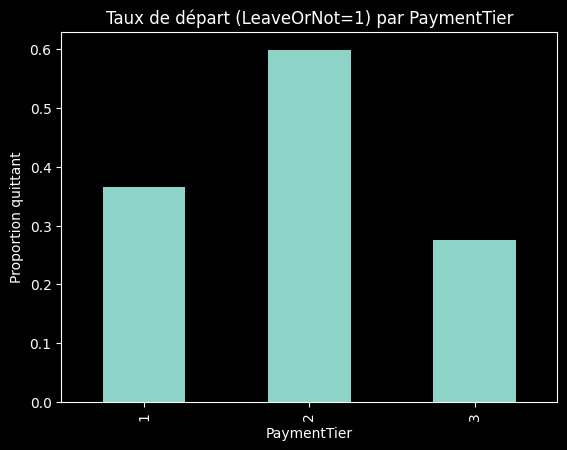

In [11]:
rate_by_tier = pd.crosstab(df["PaymentTier"], df["LeaveOrNot"], normalize="index")[1]
rate_by_tier.plot(kind="bar")
plt.title("Taux de départ (LeaveOrNot=1) par PaymentTier")
plt.xlabel("PaymentTier")
plt.ylabel("Proportion quittant")
plt.show()